# CNN-LSTM Stock Price Prediction using Financial Charts

**Name:** Abdelrahman Khalaf Ahmed Ghoneim  
**ID:** 4221407  
**Course:** Deep Learning - Sequential Data Modeling

### Architecture
- **CNN** : extracts local spatial patterns from the price window (like chart features)
- **LSTM** : captures temporal dependencies across time steps
- **Dense** : produces the final predicted price

## 1. Imports & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 2. Generate Synthetic Stock Data
Mimics real OHLCV chart data with trend, seasonality and noise.

In [3]:
np.random.seed(42)
n_days = 1000

# Simulate a stock price with trend + noise
t = np.arange(n_days)
trend      = 100 + 0.05 * t
seasonal   = 10 * np.sin(2 * np.pi * t / 252)   # yearly cycle
noise      = np.random.normal(0, 3, n_days)
close      = trend + seasonal + noise
close      = np.maximum(close, 10)                # no negative prices

# Build OHLCV columns (realistic simulation)
open_  = close + np.random.normal(0, 1, n_days)
high   = np.maximum(close, open_) + np.abs(np.random.normal(0, 1.5, n_days))
low    = np.minimum(close, open_) - np.abs(np.random.normal(0, 1.5, n_days))
volume = np.abs(np.random.normal(1e6, 2e5, n_days))

df = pd.DataFrame({
    'Open'  : open_,
    'High'  : high,
    'Low'   : low,
    'Close' : close,
    'Volume': volume
})

print("=" * 55)
print("  CNN-LSTM Stock Price Prediction")
print("  Abdelrahman Khalaf Ahmed Ghoneim | ID: 4221407")
print("=" * 55)
print(f"\nDataset shape : {df.shape}")
print(f"Price range   : {df['Close'].min():.2f}  ->  {df['Close'].max():.2f}")
df.head()

  CNN-LSTM Stock Price Prediction
  Abdelrahman Khalaf Ahmed Ghoneim | ID: 4221407

Dataset shape : (1000, 5)
Price range   : 94.91  ->  157.97


,Open,High,Low,Close,Volume
0,102.889498,103.902265,98.628431,101.490142,8.273013e+05
1,100.809148,101.025926,98.593936,99.884514,9.937593e+05
2,102.601155,103.789785,101.921116,102.541524,1.003603e+06
3,104.819454,105.928333,101.987922,105.466391,1.094526e+06
4,101.191442,104.031864,99.658389,100.493218,7.266283e+05


## 3. Feature Engineering

In [4]:
df['MA5']    = df['Close'].rolling(5).mean()
df['MA20']   = df['Close'].rolling(20).mean()
df['Return'] = df['Close'].pct_change()
df['Range']  = df['High'] - df['Low']
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA5', 'MA20', 'Return', 'Range']
target   = 'Close'

print(f"Features: {features}")
print(f"Target:   {target}")
print(f"Dataset shape after feature engineering: {df.shape}")
df.head()

Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'MA5', 'MA20', 'Return', 'Range']
Target:   Close
Dataset shape after feature engineering: (981, 9)


,Open,High,Low,Close,Volume,MA5,MA20,Return,Range
0,101.699361,103.558249,100.447584,101.275195,9.823818e+05,102.811595,102.283501,-0.012092,3.110665
1,110.702322,110.792221,108.379093,110.179486,1.433987e+06,104.304183,102.717968,0.087922,2.413127
2,104.798971,105.788737,104.104229,105.372671,7.152635e+05,105.049546,102.992376,-0.043627,1.684507
3,106.492582,108.557925,105.875442,106.516937,6.296315e+05,105.171811,103.191146,0.010859,2.682482
4,104.443488,106.406719,100.570367,102.301218,1.156718e+06,105.129101,103.032888,-0.039578,5.836352


## 4. Normalise

In [5]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]])

print(f"X_scaled shape: {X_scaled.shape}")
print(f"y_scaled shape: {y_scaled.shape}")

X_scaled shape: (981, 9)
y_scaled shape: (981, 1)


## 5. Create Sliding-Window Sequences
Each sample = window of `SEQ_LEN` days (the "chart")  
Each label = next day's close price

In [6]:
SEQ_LEN = 30   # 30-day look-back window

X_seq, y_seq = [], []
for i in range(SEQ_LEN, len(X_scaled)):
    X_seq.append(X_scaled[i - SEQ_LEN : i])   # shape (30, 9)
    y_seq.append(y_scaled[i, 0])

X_seq = np.array(X_seq)   # (samples, 30, 9)
y_seq = np.array(y_seq)   # (samples,)

# Train / Validation / Test  split  (70 / 15 / 15)
n       = len(X_seq)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X_seq[:n_train],             y_seq[:n_train]
X_val,   y_val   = X_seq[n_train:n_train+n_val], y_seq[n_train:n_train+n_val]
X_test,  y_test  = X_seq[n_train+n_val:],        y_seq[n_train+n_val:]

print(f"Train samples : {len(X_train)}")
print(f"Val   samples : {len(X_val)}")
print(f"Test  samples : {len(X_test)}")
print(f"Input shape   : {X_train.shape}  (samples, time_steps, features)")

Train samples : 665
Val   samples : 142
Test  samples : 144
Input shape   : (665, 30, 9)  (samples, time_steps, features)


## 6. Build CNN-LSTM Model

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, LSTM,
                                     Dense, Dropout, BatchNormalization,
                                     Flatten)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

model = Sequential([
    # -- CNN Block --
    # Extracts local spatial patterns from the 30-day chart window
    Conv1D(filters=64, kernel_size=3, activation='relu',
           padding='same', input_shape=(SEQ_LEN, len(features))),
    BatchNormalization(),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # -- LSTM Block --
    # Captures temporal dependencies across the sequence
    LSTM(units=100, return_sequences=True),
    Dropout(0.3),
    LSTM(units=50, return_sequences=False),
    Dropout(0.3),

    # -- Output Block --
    Dense(25, activation='relu'),
    Dense(1)                         # predicted next-day close price
])

model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 64)         │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 15, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 7, 100)         │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,717 (635.61 KB)

 Trainable params: 162,333 (634.11 KB)

 Non-trainable params: 384 (1.50 KB)

## 7. Train the Model

In [8]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

print("Training CNN-LSTM model ...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
print(f"\nTraining finished after {len(history.history['loss'])} epochs.")

Training CNN-LSTM model ...
Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0229 - mae: 0.1198 - val_loss: 0.3253 - val_mae: 0.5595 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0120 - mae: 0.0869 - val_loss: 0.3446 - val_mae: 0.5759 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0098 - mae: 0.0785 - val_loss: 0.3451 - val_mae: 0.5760 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0080 - mae: 0.0713 - val_loss: 0.3510 - val_mae: 0.5802 - learning_rate: 0.0010
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0072 - mae: 0.0685 - val_loss: 0.3257 - val_mae: 0.5577 - learning_rate: 0.0010
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0066 - mae: 0.0641 - val_loss: 0.2914 - val_mae: 0.5272 - learning_rate: 0.0010
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0067 - mae: 0.0644 - val_loss: 0.2698 - val_mae: 0.5048 - 

## 8. Evaluate on Test Set

In [9]:
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred        = scaler_y.inverse_transform(y_pred_scaled)
y_true        = scaler_y.inverse_transform(y_test.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("-" * 55)
print("Test Set Results")
print("-" * 55)
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  MAPE : {mape:.2f} %")

-------------------------------------------------------
Test Set Results
-------------------------------------------------------
  RMSE : 7.6918
  MAE  : 6.6687
  MAPE : 4.62 %


## 9. Plot Results

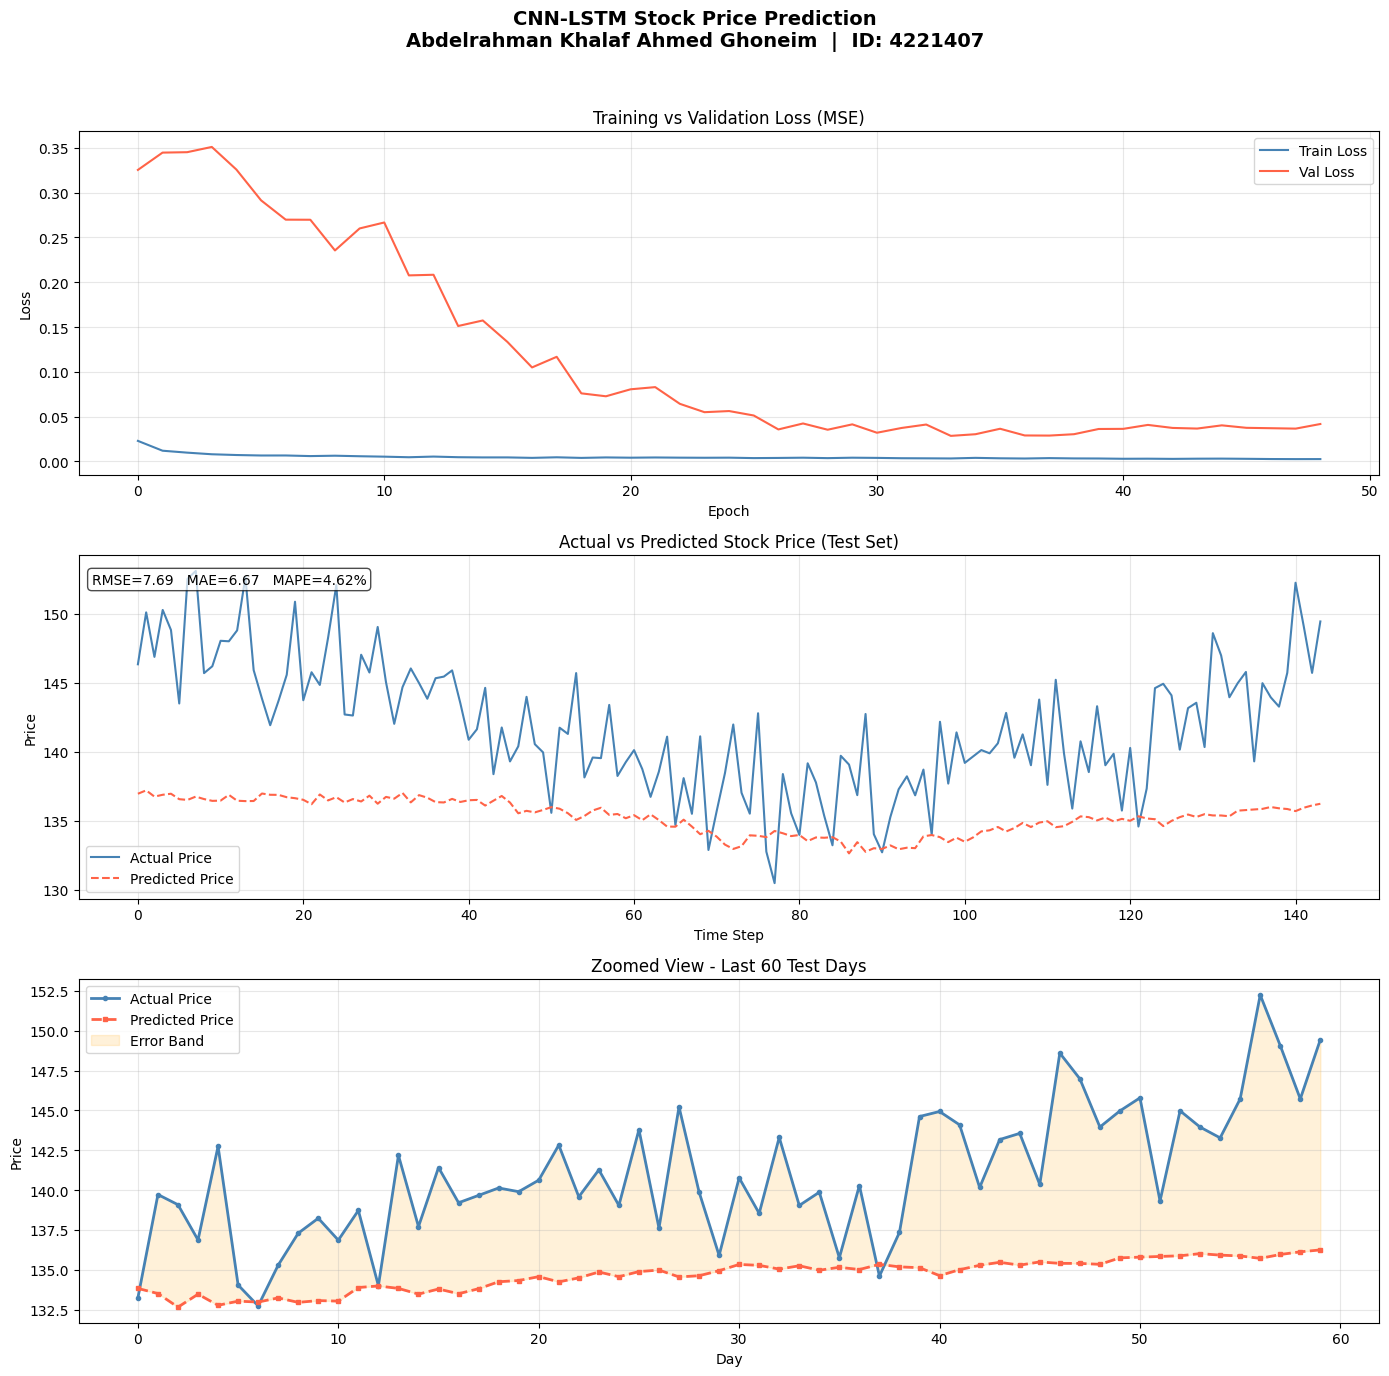

Plot saved.


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle("CNN-LSTM Stock Price Prediction\n"
             "Abdelrahman Khalaf Ahmed Ghoneim  |  ID: 4221407",
             fontsize=14, fontweight='bold')

# -- Plot 1: Training & Validation Loss
ax = axes[0]
ax.plot(history.history['loss'],     label='Train Loss', color='steelblue')
ax.plot(history.history['val_loss'], label='Val Loss',   color='tomato')
ax.set_title("Training vs Validation Loss (MSE)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# -- Plot 2: Actual vs Predicted (full test set)
ax = axes[1]
ax.plot(y_true,  label='Actual Price',    color='steelblue', linewidth=1.5)
ax.plot(y_pred,  label='Predicted Price', color='tomato',    linewidth=1.5, linestyle='--')
ax.set_title("Actual vs Predicted Stock Price (Test Set)")
ax.set_xlabel("Time Step")
ax.set_ylabel("Price")
ax.legend()
ax.grid(True, alpha=0.3)

# -- Plot 3: Zoomed last 60 days
ax = axes[2]
zoom = 60
ax.plot(y_true[-zoom:],  label='Actual Price',    color='steelblue', linewidth=2,   marker='o', markersize=3)
ax.plot(y_pred[-zoom:],  label='Predicted Price', color='tomato',    linewidth=2,   linestyle='--', marker='s', markersize=3)
ax.fill_between(range(zoom),
                y_true[-zoom:].flatten(),
                y_pred[-zoom:].flatten(),
                alpha=0.15, color='orange', label='Error Band')
ax.set_title(f"Zoomed View - Last {zoom} Test Days")
ax.set_xlabel("Day")
ax.set_ylabel("Price")
ax.legend()
ax.grid(True, alpha=0.3)

# Metrics annotation on plot 2
axes[1].text(0.01, 0.95,
             f"RMSE={rmse:.2f}   MAE={mae:.2f}   MAPE={mape:.2f}%",
             transform=axes[1].transAxes, fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('cnn_lstm_stock_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 10. Save Model

In [11]:
model.save('cnn_lstm_stock_model.keras')
print("Model saved.")
print("\nDone!")

Model saved.

Done!
